## Configuración del Entorno de Visualización

In [3]:
# Importación de librerías para manipulación y visualización de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración estética global para que los gráficos luzcan profesionales
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6) # Tamaño por defecto

# Carga del dataset limpio
df = pd.read_csv('bank_limpio_para_graficos.csv')

print("Entorno de visualización configurado y datos cargados.")

Entorno de visualización configurado y datos cargados.


# Bloque 1: Visión General y Demografía Básica

## Gráfico 1: Distribución de la Variable Objetivo (Tasa Base)

1. Visión General: Tasa de Conversión de Depósitos a Plazo

Justificación: Este gráfico de torta establece la línea base del problema de negocio. Muestra visualmente la baja tasa de conversión de los depósitos a plazo, evidenciando el desafío principal al que se enfrenta el Banco Financiero Global. Identificar esta proporción de forma clara es el primer paso para justificar la necesidad de modelos predictivos y nuevas estrategias de marketing.

C:\Users\diego\AppData\Local\Temp\ipykernel_13044\2605171264.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conteo_y.index, y=conteo_y.values, palette=['#A93226', '#1B4F72'], edgecolor='black')


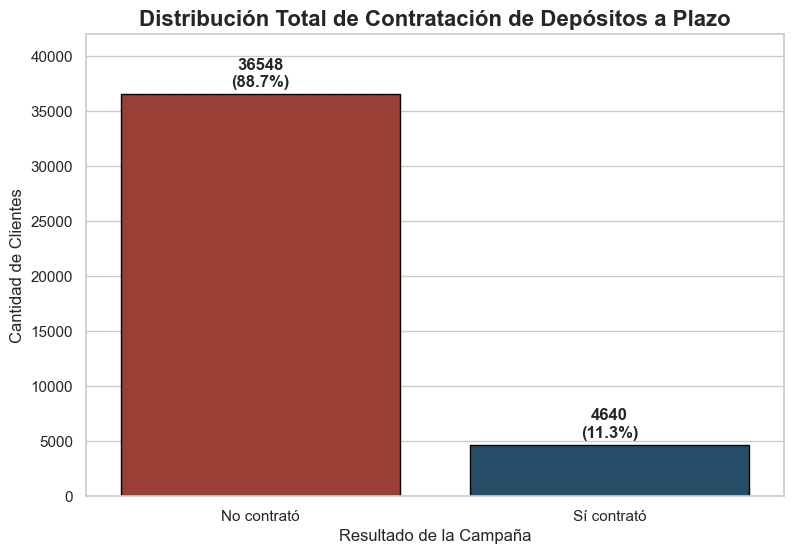

In [4]:
# Gráfico 1: Gráfico de Barras para la variable objetivo 'y'
plt.figure(figsize=(9, 6))

# Calculamos los conteos y mapeamos para que las etiquetas estén en español
conteo_y = df['y'].value_counts()
conteo_y.index = ['No contrató', 'Sí contrató']

# Generación del gráfico de barras con Seaborn
ax = sns.barplot(x=conteo_y.index, y=conteo_y.values, palette=['#A93226', '#1B4F72'], edgecolor='black')

plt.title('Distribución Total de Contratación de Depósitos a Plazo', fontsize=16, fontweight='bold')
plt.xlabel('Resultado de la Campaña', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Añadimos etiquetas de datos sobre cada barra (valor absoluto y porcentaje)
total = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    valor = int(p.get_height())
    ax.annotate(f'{valor}\n({porcentaje})', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontweight='bold')

plt.ylim(0, max(conteo_y.values) * 1.15) # Damos espacio para las etiquetas
plt.show()

## Gráfico 2: Distribución de la Edad de los Clientes

2. Perfil Demográfico: Distribución de Edad de la Cartera Contactada

Justificación: Mediante un histograma, observamos la distribución de edades de la cartera de clientes que el banco ha contactado. Esto permite a la organización evaluar si el esfuerzo de marketing se está dirigiendo al segmento demográfico correcto o si existe un sesgo en la base de datos hacia ciertas edades.

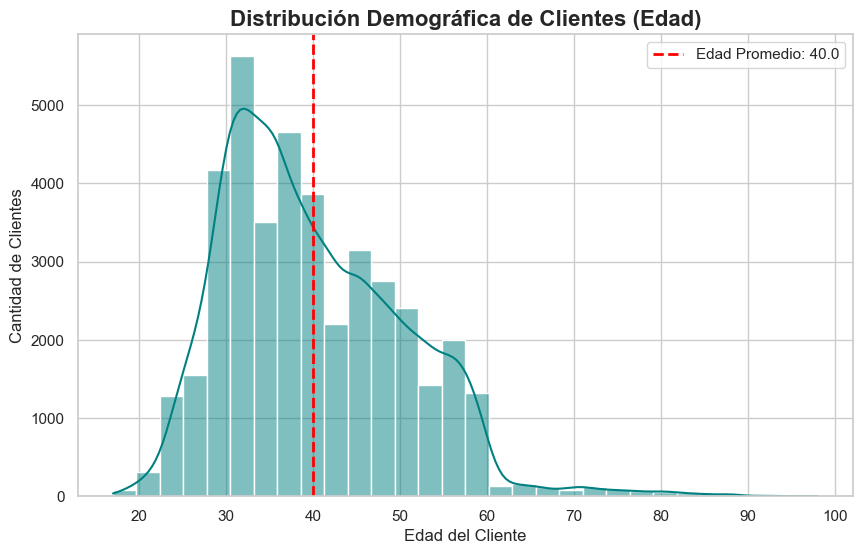

In [5]:
# Gráfico 2: Histograma de Edad
plt.figure(figsize=(10, 6))

# Usamos seaborn para crear un histograma con curva de densidad (KDE)
sns.histplot(data=df, x='age', bins=30, kde=True, color='teal')

plt.title('Distribución Demográfica de Clientes (Edad)', fontsize=16, fontweight='bold')
plt.xlabel('Edad del Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Añadimos una línea vertical para marcar la edad promedio
plt.axvline(df['age'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Edad Promedio: {df["age"].mean():.1f}')
plt.legend()
plt.show()

## Gráfico 3: Relación entre Edad y Contratación

3. Relación Demográfica: Edad frente al Éxito de Conversión

Justificación: El uso de un diagrama de caja (boxplot) permite determinar la distribución estadística de la edad frente al éxito de la campaña ("sí" o "no"). Ayuda al cliente a identificar visualmente si existen variaciones significativas y si los perfiles más jóvenes o de mayor edad presentan una propensión diferente a contratar el producto.

C:\Users\diego\AppData\Local\Temp\ipykernel_13044\681085793.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_map, y=df['age'], palette=['#A93226', '#1B4F72'])


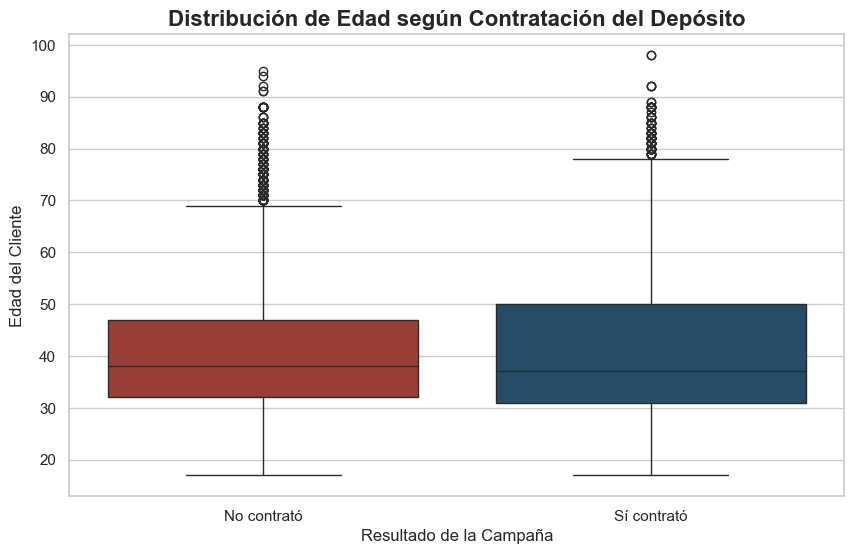

In [35]:
# Gráfico 3: Boxplot de Edad vs Conversión
plt.figure(figsize=(10, 6))

# Creamos una copia temporal de la columna 'y' para mapear a texto y mejorar la legibilidad del gráfico
y_map = df['y'].map({0: 'No contrató', 1: 'Sí contrató'})

# Generación del Boxplot
sns.boxplot(x=y_map, y=df['age'], palette=['#A93226', '#1B4F72'])

plt.title('Distribución de Edad según Contratación del Depósito', fontsize=16, fontweight='bold')
plt.xlabel('Resultado de la Campaña', fontsize=12)
plt.ylabel('Edad del Cliente', fontsize=12)
plt.show()

## Gráfico 4: Profesión y Tasa de Éxito

4. Perfil Profesional: Tasa de Conversión por Tipo de Trabajo
Justificación: Un gráfico de barras horizontales ordenado es la herramienta más persuasiva para comparar categorías múltiples. Muestra qué profesiones tienen mayor éxito relativo en la contratación del depósito. Este insight es clave para que la gerencia redirija el presupuesto de futuras campañas hacia los segmentos ocupacionales más rentables.

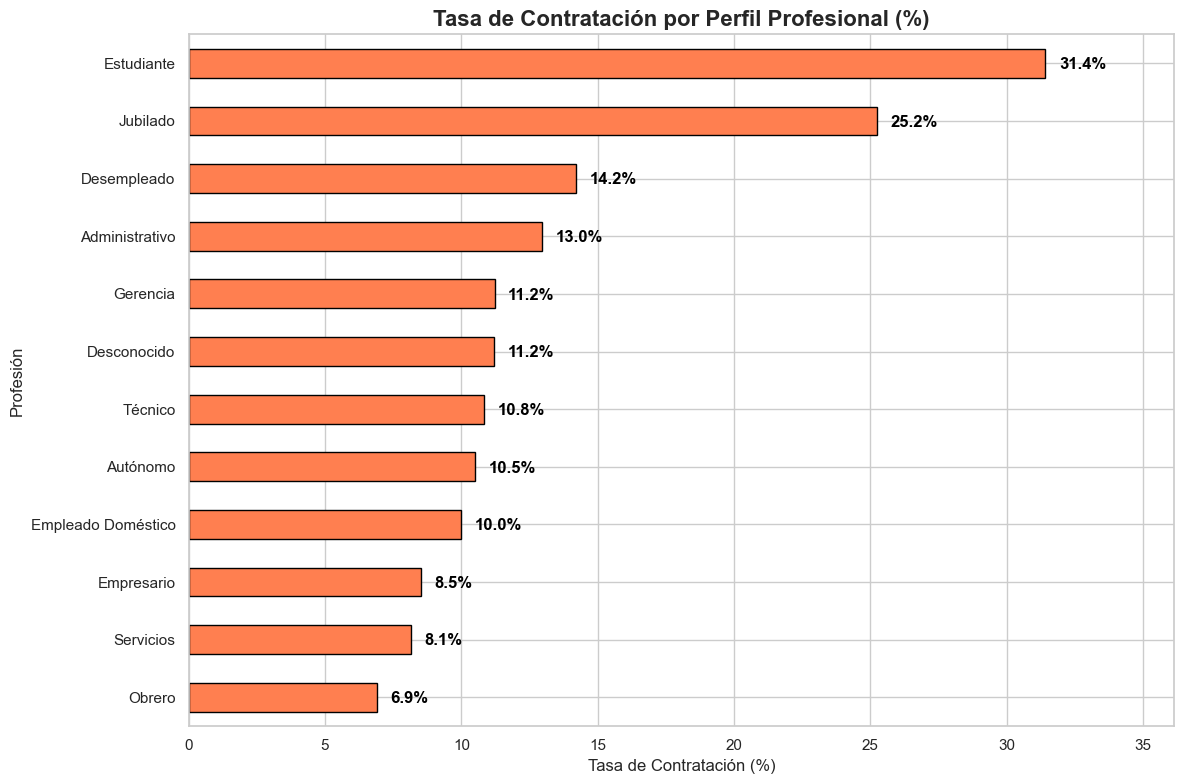

In [7]:
# Gráfico 4: Tasa de contratación por tipo de profesión (job)
plt.figure(figsize=(12, 8))

# 1. Diccionario de traducción para las profesiones
trad_profesiones = {
    'admin': 'Administrativo', 
    'blue-collar': 'Obrero', 
    'entrepreneur': 'Empresario', 
    'housemaid': 'Empleado Doméstico', 
    'management': 'Gerencia', 
    'retired': 'Jubilado', 
    'self-employed': 'Autónomo', 
    'services': 'Servicios', 
    'student': 'Estudiante', 
    'technician': 'Técnico', 
    'unemployed': 'Desempleado', 
    'unknown': 'Desconocido'
}

# Aplicamos la traducción a una copia temporal para no alterar el dataframe original
df_plot = df.copy()
df_plot['job'] = df_plot['job'].map(trad_profesiones)

# 2. Agrupamos por 'job' y calculamos el promedio de 'y' (Tasa de Contratación)
# Multiplicamos por 100 para obtener porcentaje y ordenamos de mayor a menor
tasa_job = df_plot.groupby('job')['y'].mean().sort_values(ascending=True) * 100

# 3. Generación del gráfico de barras horizontales
barplot = tasa_job.plot(kind='barh', color='coral', edgecolor='black')

# Actualizamos los títulos con el nuevo vocabulario bancario
plt.title('Tasa de Contratación por Perfil Profesional (%)', fontsize=16, fontweight='bold')
plt.xlabel('Tasa de Contratación (%)', fontsize=12)
plt.ylabel('Profesión', fontsize=12)

# Añadimos las etiquetas de datos al final de cada barra para mayor claridad
for i, v in enumerate(tasa_job):
    plt.text(v + 0.5, i - 0.1, f'{v:.1f}%', color='black', fontweight='bold')

# Expandimos un poco el límite X para que las etiquetas no se corten
plt.xlim(0, max(tasa_job) * 1.15)
plt.tight_layout()
plt.show()

# Bloque 2: Perfil Socioeconómico y Financiero

## Gráfico 5: Nivel Educativo y Propensión al Ahorro

5. Perfil Socioeconómico: Tasa de Conversión según Nivel Educativo

Justificación: Este gráfico de barras apiladas al 100% permite al equipo de marketing entender la proporción exacta de éxito y fracaso dentro de cada nivel educativo. Revela si existe una correlación entre una mayor educación formal (ej. título universitario) y la propensión a adquirir productos de ahorro, lo cual ayuda a segmentar el mensaje de la campaña para que sea más efectivo y persuasivo para el cliente.

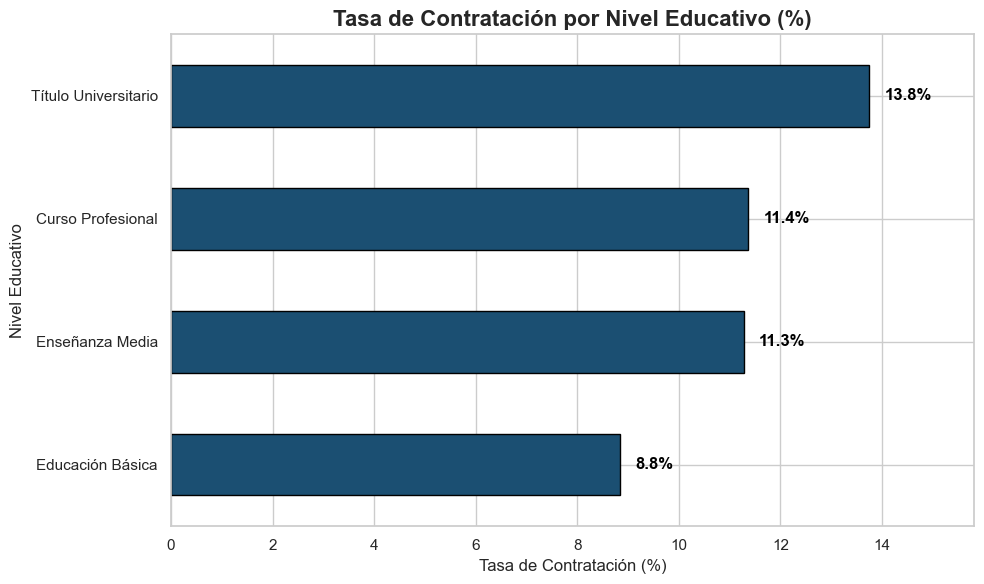

In [21]:
# Gráfico 5: Tasa de contratación por nivel educativo (education)
plt.figure(figsize=(10, 6))

# 1. Diccionario de traducción para los niveles educativos
trad_educacion = {
    'basic': 'Educación Básica',
    'high.school': 'Enseñanza Media',
    'professional.course': 'Curso Profesional',
    'university.degree': 'Título Universitario'
}

# Aplicamos la traducción a una copia temporal
df_plot_edu = df.copy()
df_plot_edu['education'] = df_plot_edu['education'].map(trad_educacion)

# 2. Calculamos la tasa de contratación (%) por educación y ordenamos
tasa_edu = df_plot_edu.groupby('education')['y'].mean().sort_values(ascending=True) * 100

# 3. Generación del gráfico de barras horizontales
ax = tasa_edu.plot(kind='barh', color='#1B4F72', edgecolor='black')

plt.title('Tasa de Contratación por Nivel Educativo (%)', fontsize=16, fontweight='bold')
plt.xlabel('Tasa de Contratación (%)', fontsize=12)
plt.ylabel('Nivel Educativo', fontsize=12)

# Añadimos las etiquetas de porcentaje al final de cada barra
for i, v in enumerate(tasa_edu):
    plt.text(v + 0.3, i, f'{v:.1f}%', color='black', va='center', fontweight='bold')

plt.xlim(0, max(tasa_edu) * 1.15)
plt.tight_layout()
plt.show()

## Gráfico 6: Estado Civil y Tasa de Éxito

6. Perfil Demográfico-Financiero: Estado Civil frente a Tasa de Conversión

Justificación: Utilizando un gráfico de barras, evaluamos los patrones de liquidez de los clientes. Este análisis permite a la gerencia descubrir, por ejemplo, si los clientes solteros disponen de mayor flexibilidad financiera para invertir en depósitos a plazo en comparación con los clientes casados. La información obtenida es vital para ajustar la oferta de valor.

C:\Users\diego\AppData\Local\Temp\ipykernel_13044\3456889617.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_marital = sns.barplot(x=tasa_marital.index, y=tasa_marital.values, palette='viridis', edgecolor='black')


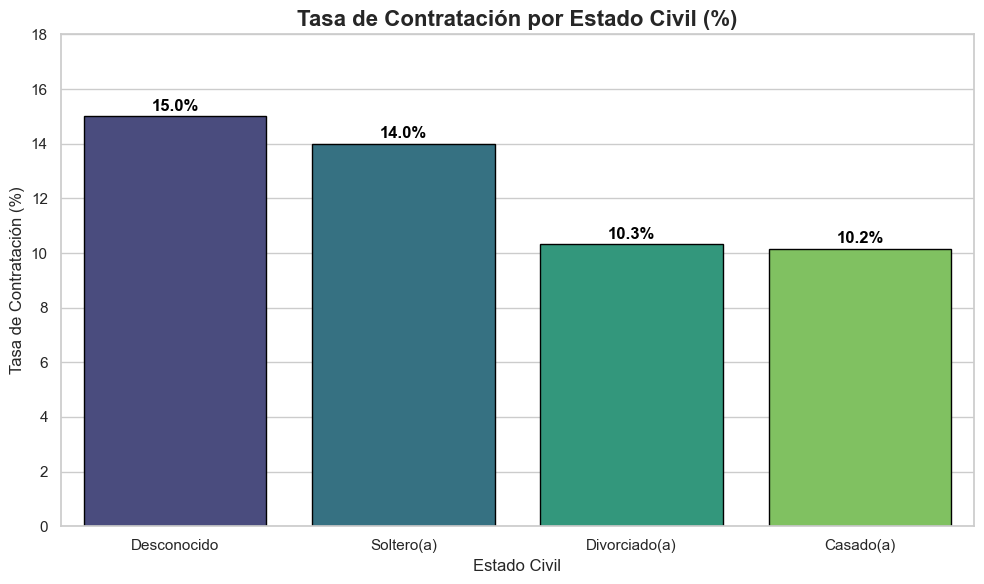

In [9]:
# Gráfico 6: Tasa de contratación por estado civil (marital)
plt.figure(figsize=(10, 6))

# 1. Diccionario de traducción para el estado civil
trad_estado_civil = {
    'married': 'Casado(a)',
    'single': 'Soltero(a)',
    'divorced': 'Divorciado(a)',
    'unknown': 'Desconocido'
}

# Aplicamos la traducción a una copia temporal
df_plot_marital = df.copy()
df_plot_marital['marital'] = df_plot_marital['marital'].map(trad_estado_civil)

# 2. Calculamos la tasa de contratación (%) por estado civil
tasa_marital = df_plot_marital.groupby('marital')['y'].mean().sort_values(ascending=False) * 100

# 3. Generación del gráfico de barras
barplot_marital = sns.barplot(x=tasa_marital.index, y=tasa_marital.values, palette='viridis', edgecolor='black')

plt.title('Tasa de Contratación por Estado Civil (%)', fontsize=16, fontweight='bold')
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Tasa de Contratación (%)', fontsize=12)

# Añadimos los valores porcentuales sobre cada barra
for i, v in enumerate(tasa_marital.values):
    barplot_marital.text(i, v + 0.2, f'{v:.1f}%', ha='center', color='black', fontweight='bold')

plt.ylim(0, max(tasa_marital.values) + 3) 
plt.tight_layout()
plt.show()

## Gráfico 7: Impacto del Crédito Hipotecario

7. Estado Financiero: Impacto de la Carga Hipotecaria en la Conversión

Justificación: Este gráfico de barras agrupadas responde a una hipótesis de negocio crítica: ¿Tener una deuda a largo plazo (hipoteca) frena la contratación de nuevos productos de ahorro?. Identificar este comportamiento previene que el banco gaste recursos llamando a clientes cuya carga financiera mensual les impide invertir, optimizando así la eficiencia de la campaña.

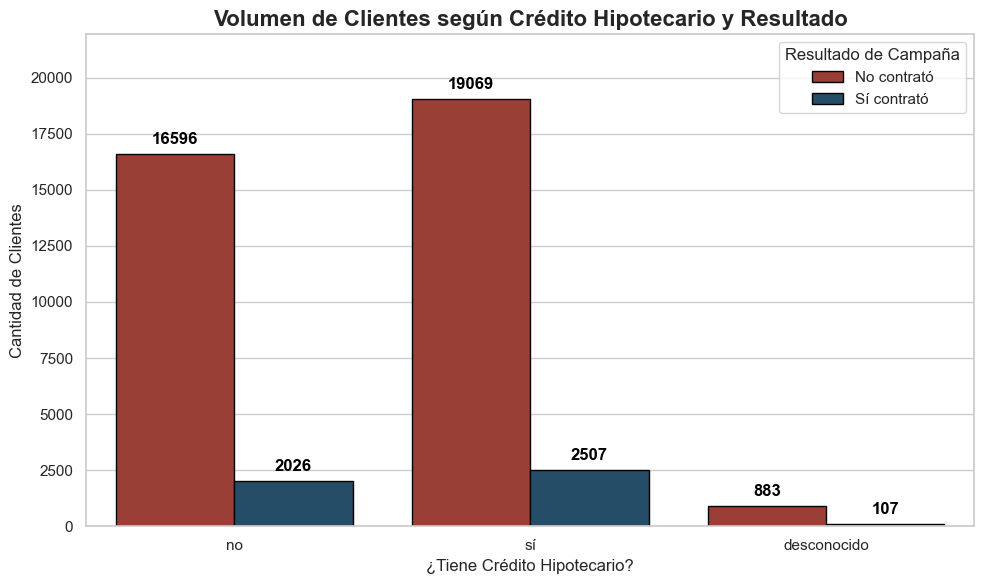

In [22]:
# Gráfico 7: Gráfico de Barras Agrupadas de housing vs y
plt.figure(figsize=(10, 6))

# Generación del gráfico de barras agrupadas (countplot cuenta las cantidades absolutas)
ax = sns.countplot(data=df, x='housing', hue='y', palette=['#A93226', '#1B4F72'], edgecolor='black')

plt.title('Volumen de Clientes según Crédito Hipotecario y Resultado', fontsize=16, fontweight='bold')
plt.xlabel('¿Tiene Crédito Hipotecario?', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Modificamos la leyenda para que hable en términos de negocio
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ['No contrató', 'Sí contrató'], title='Resultado de Campaña')

# Añadimos las cantidades exactas sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    # Verificamos que la altura sea un número válido (evita errores con barras vacías)
    if not pd.isna(altura) and altura > 0:
        valor = int(altura)
        ax.annotate(f'{valor}', (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', 
                    fontweight='bold', color='black')

# Obtenemos la altura máxima para darle un margen del 15% al eje Y y que los números no se corten
altura_max = max([p.get_height() for p in ax.patches if not pd.isna(p.get_height())])
plt.ylim(0, altura_max * 1.15)

plt.tight_layout()
plt.show()

## Gráfico 8: Impacto del Préstamo Personal

8. Estado Financiero: Impacto de Préstamos de Consumo (Corto Plazo)

Justificación: Como complemento al análisis hipotecario, este gráfico evalúa el efecto de los préstamos personales (deudas de corto o mediano plazo). Permite visualizar de forma clara y efectiva si el apalancamiento financiero general es un factor de rechazo sistemático del producto bancario ofrecido, ayudando a refinar los criterios de segmentación del modelo predictivo.

C:\Users\diego\AppData\Local\Temp\ipykernel_13044\1434001013.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tasa_prestamo.index, y=tasa_prestamo.values, palette='magma', edgecolor='black')


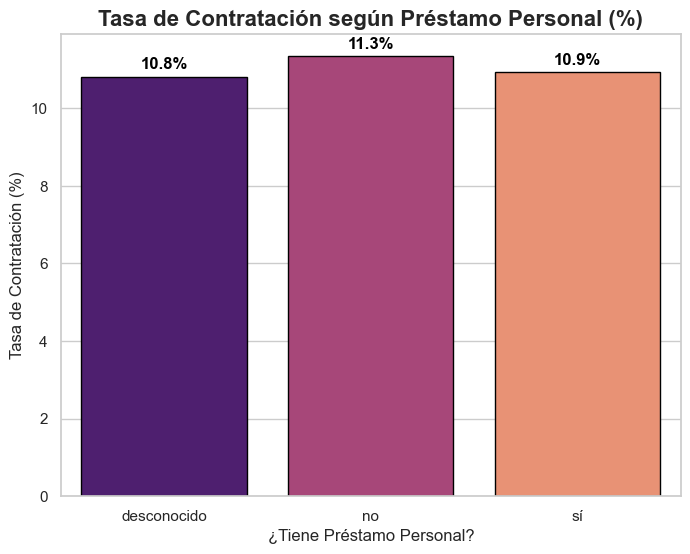

In [11]:
# Gráfico 8: Tasa de conversión de clientes con o sin préstamo personal (loan)
plt.figure(figsize=(8, 6))

# Aquí graficaremos la tasa de conversión en lugar del volumen absoluto para dar otra perspectiva analítica
tasa_prestamo = df.groupby('loan')['y'].mean() * 100

ax = sns.barplot(x=tasa_prestamo.index, y=tasa_prestamo.values, palette='magma', edgecolor='black')

plt.title('Tasa de Contratación según Préstamo Personal (%)', fontsize=16, fontweight='bold')
plt.xlabel('¿Tiene Préstamo Personal?', fontsize=12)
plt.ylabel('Tasa de Contratación (%)', fontsize=12)

# Añadimos los valores porcentuales
for i, v in enumerate(tasa_prestamo.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', color='black', fontweight='bold')

plt.show()

# Bloque 3: Operativa y Ejecución de Campaña

## Gráfico 9: Estacionalidad de las Ventas (Mes a Mes)

9. Ejecución Operativa: Estacionalidad y Tasa de Conversión Mensual

Justificación: Este gráfico de barras revela la estacionalidad del negocio bancario al ordenar la tasa de conversión cronológicamente. Es una herramienta estratégica para que la gerencia identifique los meses "valle" y "pico", permitiendo una asignación de presupuesto publicitario mucho más inteligente y anticipando las épocas donde el cliente tiene mayor disposición a inmovilizar capital en depósitos a plazo.  

C:\Users\diego\AppData\Local\Temp\ipykernel_13044\869750076.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tasa_mes.index, y=tasa_mes.values, palette='coolwarm', edgecolor='black')


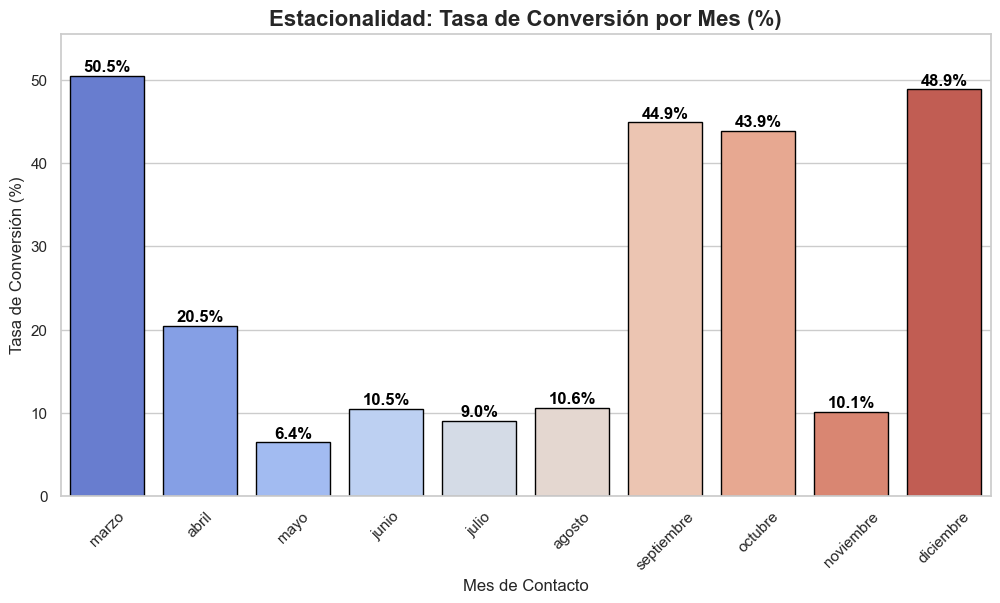

In [12]:
# Gráfico 9: Tasa de conversión mensual (month)
plt.figure(figsize=(12, 6))

# Definimos el orden cronológico lógico para los meses disponibles en el dataset
orden_meses = ['marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']

# Calculamos la tasa de conversión, reindexamos para mantener el orden cronológico y multiplicamos por 100
tasa_mes = df.groupby('month')['y'].mean().reindex(orden_meses) * 100

# Generación del gráfico de barras
ax = sns.barplot(x=tasa_mes.index, y=tasa_mes.values, palette='coolwarm', edgecolor='black')

plt.title('Estacionalidad: Tasa de Conversión por Mes (%)', fontsize=16, fontweight='bold')
plt.xlabel('Mes de Contacto', fontsize=12)
plt.ylabel('Tasa de Conversión (%)', fontsize=12)

# Rotamos las etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=45)

# Añadimos las etiquetas de datos sobre las barras
for i, v in enumerate(tasa_mes.values):
    # Algunos meses podrían no tener datos en el cruce (NaN), lo controlamos
    if not np.isnan(v):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', color='black', fontweight='bold')

plt.ylim(0, max(tasa_mes.dropna()) + 5)
plt.show()

## Gráfico 10: Canal de Comunicación

10. Ejecución Operativa: Efectividad del Canal de Contacto

Justificación: Un gráfico de barras agrupadas que compara la efectividad del teléfono celular frente al fijo. En la era digital, entender por cuál canal el cliente está más receptivo para aceptar un producto financiero dicta las políticas de recolección de datos (ej. exigir número de celular al abrir una cuenta) y optimiza las herramientas de call center.

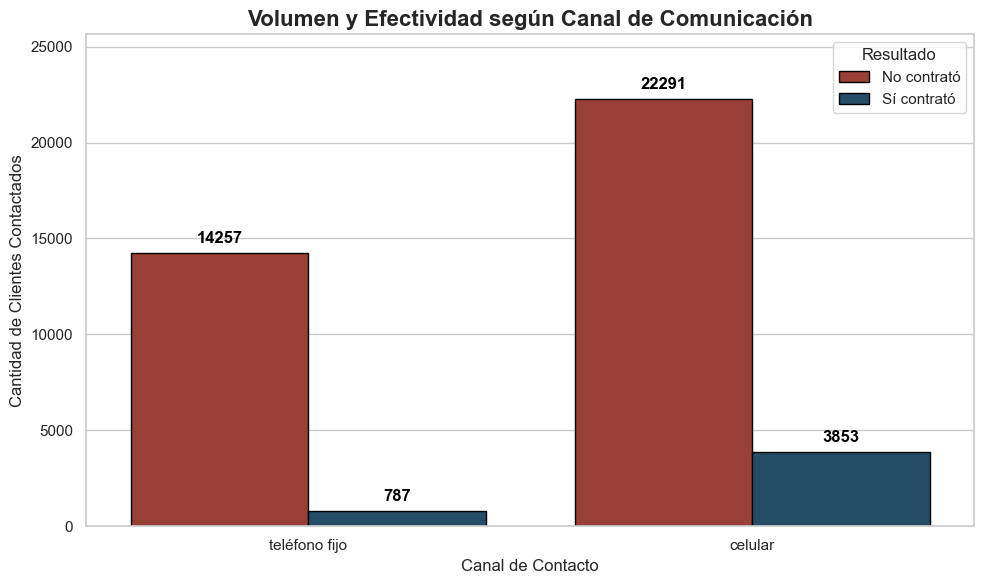

In [23]:
# Gráfico 10: Comparación del volumen y éxito según tipo de contacto
plt.figure(figsize=(10, 6))

# Usamos countplot para ver tanto el volumen de llamadas como la proporción de éxito
ax = sns.countplot(data=df, x='contact', hue='y', palette=['#A93226', '#1B4F72'], edgecolor='black')

plt.title('Volumen y Efectividad según Canal de Comunicación', fontsize=16, fontweight='bold')
plt.xlabel('Canal de Contacto', fontsize=12)
plt.ylabel('Cantidad de Clientes Contactados', fontsize=12)

# Ajustamos la leyenda
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ['No contrató', 'Sí contrató'], title='Resultado', loc='upper right')

# Añadimos las cantidades exactas sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    if not pd.isna(altura) and altura > 0:
        valor = int(altura)
        ax.annotate(f'{valor}', (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', 
                    fontweight='bold', color='black')

# Ampliamos el eje Y para que los números más altos no queden cortados por el borde superior
altura_max = max([p.get_height() for p in ax.patches if not pd.isna(p.get_height())])
plt.ylim(0, altura_max * 1.15)

plt.tight_layout()
plt.show()

## Gráfico 11: Esfuerzo de Campaña (Distribución de Llamadas)

11. Logística de Campaña: Distribución del Número de Contactos
Justificación: Este histograma discreto audita el esfuerzo de ventas. Muestra cuántas veces se insistió a los clientes durante la campaña actual (recordando que previamente limitamos los valores extremos atípicos para no sesgar el análisis). Permite al cliente evaluar si el equipo comercial está dedicando demasiado tiempo a "perseguir" clientes o si la distribución de llamadas es saludable.

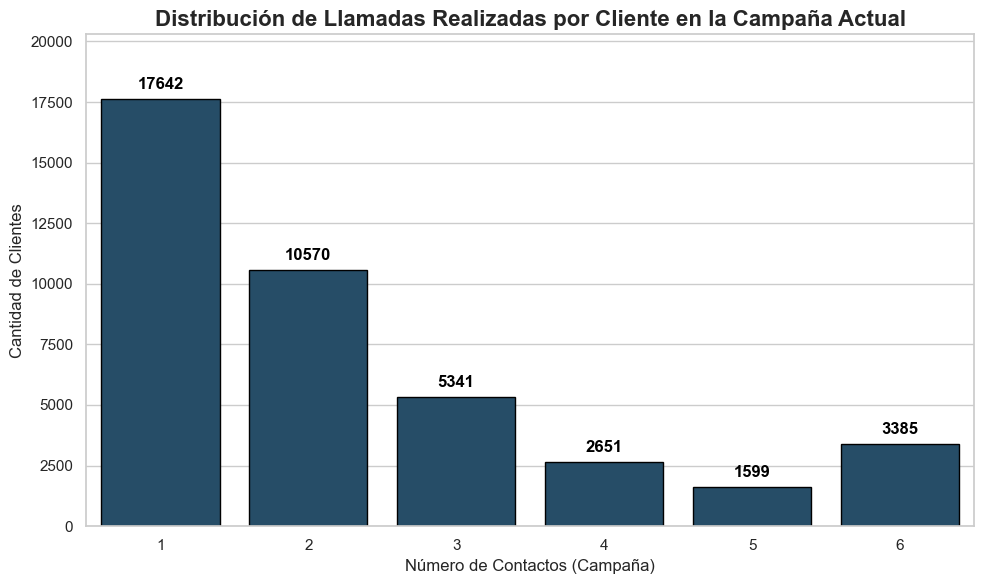

In [20]:
# Gráfico 11: Histograma del número de contactos por campaña
plt.figure(figsize=(10, 6))

# 1. Creamos una copia y convertimos 'campaign' a entero (int) para eliminar los decimales (.0)
df_plot_camp = df.copy()
df_plot_camp['campaign'] = df_plot_camp['campaign'].astype(int)

# 2. Usamos countplot con la nueva variable entera
ax = sns.countplot(data=df_plot_camp, x='campaign', color='#1B4F72', edgecolor='black')

plt.title('Distribución de Llamadas Realizadas por Cliente en la Campaña Actual', fontsize=16, fontweight='bold')
plt.xlabel('Número de Contactos (Campaña)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# 3. Agregamos los conteos exactos sobre cada barra (igual que en los gráficos 7 y 10)
for p in ax.patches:
    altura = p.get_height()
    if not pd.isna(altura) and altura > 0:
        valor = int(altura)
        ax.annotate(f'{valor}', (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', 
                    fontweight='bold', color='black')

# Ampliamos el eje Y para que los números no queden cortados por el borde superior
altura_max = max([p.get_height() for p in ax.patches if not pd.isna(p.get_height())])
plt.ylim(0, altura_max * 1.15)

plt.tight_layout()
plt.show()

## Gráfico 12: Fatiga del Cliente (Llamadas vs Éxito)

12. Límite Operativo: Umbral de Fatiga del Cliente por Insistencia

Justificación: A través de un boxplot, cruzamos el número de llamadas con el resultado final de la campaña. Este es uno de los gráficos con mayor valor persuasivo para la toma de decisiones, ya que demuestra empíricamente a partir de qué número de contactos el cliente empieza a rechazar la oferta exclusivamente por fatiga o molestia, dictando un "límite de insistencia" ético y económico para la organización.

C:\Users\diego\AppData\Local\Temp\ipykernel_13044\689545980.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_plot_fatiga, x='y_str', y='campaign', palette=['#A93226', '#1B4F72'])
C:\Users\diego\AppData\Local\Temp\ipykernel_13044\689545980.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


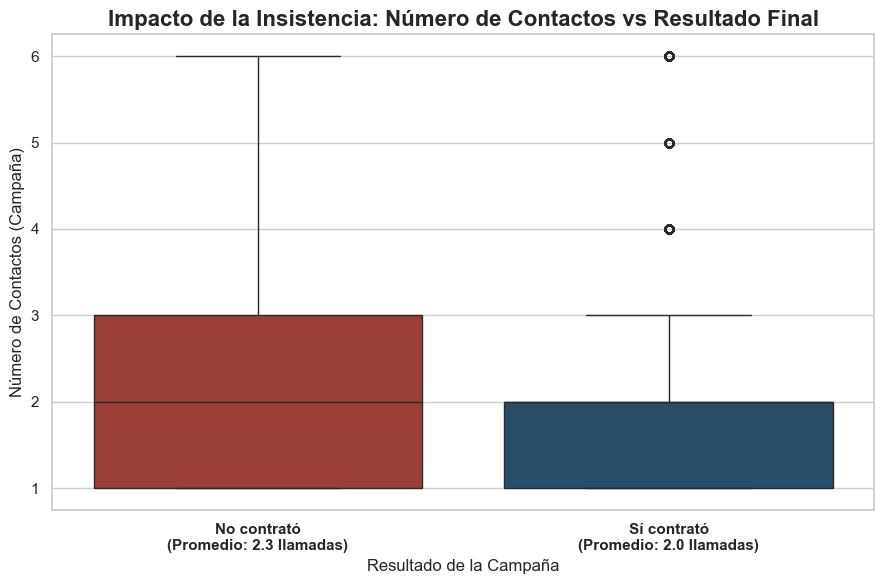

In [24]:
# Gráfico 12: Boxplot de número de contactos vs Resultado
plt.figure(figsize=(9, 6))

# 1. Mapeo temporal para la visualización
df_plot_fatiga = df.copy()
df_plot_fatiga['y_str'] = df_plot_fatiga['y'].map({0: 'No contrató', 1: 'Sí contrató'})

# 2. Generamos el boxplot
ax = sns.boxplot(data=df_plot_fatiga, x='y_str', y='campaign', palette=['#A93226', '#1B4F72'])

plt.title('Impacto de la Insistencia: Número de Contactos vs Resultado Final', fontsize=16, fontweight='bold')
plt.xlabel('Resultado de la Campaña', fontsize=12)
plt.ylabel('Número de Contactos (Campaña)', fontsize=12)

# 3. Calculamos los promedios
promedio_no = df[df['y'] == 0]['campaign'].mean()
promedio_si = df[df['y'] == 1]['campaign'].mean()

# 4. Actualizamos las etiquetas del eje X para incluir el promedio usando un salto de línea (\n)
ax.set_xticklabels([
    f'No contrató\n(Promedio: {promedio_no:.1f} llamadas)', 
    f'Sí contrató\n(Promedio: {promedio_si:.1f} llamadas)'
], fontweight='bold')

plt.tight_layout()
plt.show()

# Bloque 4: Fidelización y Contexto Macroeconómico

## Gráfico 13: Fidelización e Histórico (Campaña Anterior)

13. Fidelización: Efectividad según Resultados de Campañas Anteriores

Justificación: Este gráfico de barras revela el enorme valor de la fidelización. Al analizar el atributo poutcome (resultado de la campaña anterior), demostramos visualmente si convencer a un cliente que ya confió en el banco (éxito previo) es más fácil que adquirir uno nuevo (inexistente). Esta información justifica la creación de programas de retención VIP y reduce los costos de adquisición de clientes (CAC).

C:\Users\diego\AppData\Local\Temp\ipykernel_13044\2291271844.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tasa_poutcome.index, y=tasa_poutcome.values, palette=colores_poutcome, edgecolor='black')


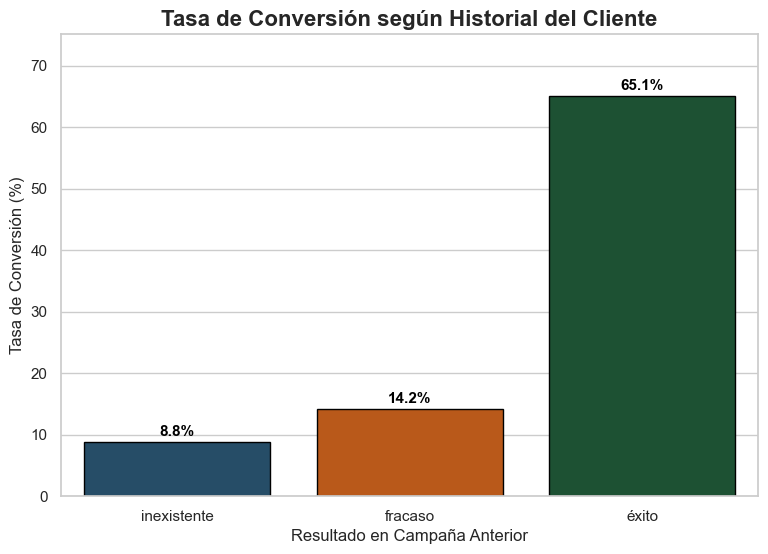

In [27]:
# Gráfico 13: Tasa de conversión según resultado de la campaña anterior (poutcome)
plt.figure(figsize=(9, 6))

# Calculamos la tasa de conversión por resultado anterior y pasamos a porcentaje
tasa_poutcome = df.groupby('poutcome')['y'].mean().sort_values() * 100

# Colores estratégicos: gris para inexistente, rojo para fracaso, verde para éxito
colores_poutcome = ['#1B4F72', '#D35400', '#145A32']

ax = sns.barplot(x=tasa_poutcome.index, y=tasa_poutcome.values, palette=colores_poutcome, edgecolor='black')

plt.title('Tasa de Conversión según Historial del Cliente', fontsize=16, fontweight='bold')
plt.xlabel('Resultado en Campaña Anterior', fontsize=12)
plt.ylabel('Tasa de Conversión (%)', fontsize=12)

# Etiquetas de datos
for i, v in enumerate(tasa_poutcome.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', color='black', fontweight='bold', fontsize=11)

plt.ylim(0, max(tasa_poutcome.values) + 10)
plt.show()

## Gráfico 14: Contexto Macroeconómico (Dispersión)

14. Entorno Macroeconómico: Concentración del Éxito ante Crisis

Justificación: A través de gráficos de densidad (KDE), analizamos cómo los factores externos moldean la decisión de ahorro. Al aislar las distribuciones, se evidencia claramente que la masa de clientes que contratan depósitos a plazo ("Sí contrató") se concentra fuertemente cuando el Euribor es bajo y cuando la tasa de variación del empleo es negativa. Este hallazgo permite a la gerencia adoptar una estrategia "contracíclica", intensificando el esfuerzo comercial justo cuando los indicadores macroeconómicos entran en zonas de enfriamiento o incertidumbre.

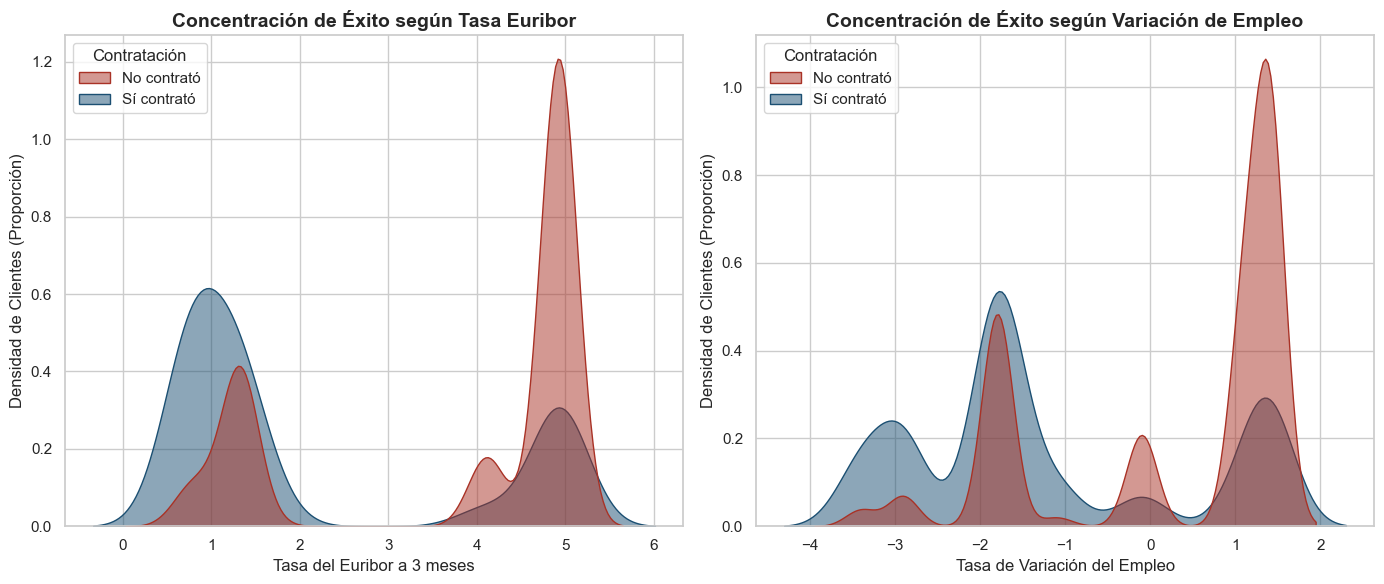

In [28]:
# Gráfico 14: Gráficos de Densidad (KDE) para variables macroeconómicas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Mapeo temporal: Renombramos la columna a 'Contratación' para que aparezca así en la leyenda
df_temp = df.copy()
df_temp['Contratación'] = df_temp['y'].map({0: 'No contrató', 1: 'Sí contrató'})
colores_densidad = {'No contrató': "#A93226", 'Sí contrató': "#1B4F72"}

# 2. Subgráfico 1: Impacto del Euribor (Usamos hue='Contratación')
sns.kdeplot(data=df_temp, x='euribor3m', hue='Contratación', fill=True, 
            common_norm=False, palette=colores_densidad, alpha=0.5, ax=axes[0])
axes[0].set_title('Concentración de Éxito según Tasa Euribor', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tasa del Euribor a 3 meses', fontsize=12)
axes[0].set_ylabel('Densidad de Clientes (Proporción)', fontsize=12)

# 3. Subgráfico 2: Impacto del Empleo (Usamos hue='Contratación')
sns.kdeplot(data=df_temp, x='emp.var.rate', hue='Contratación', fill=True, 
            common_norm=False, palette=colores_densidad, alpha=0.5, ax=axes[1])
axes[1].set_title('Concentración de Éxito según Variación de Empleo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tasa de Variación del Empleo', fontsize=12)
axes[1].set_ylabel('Densidad de Clientes (Proporción)', fontsize=12)

plt.tight_layout()
plt.show()

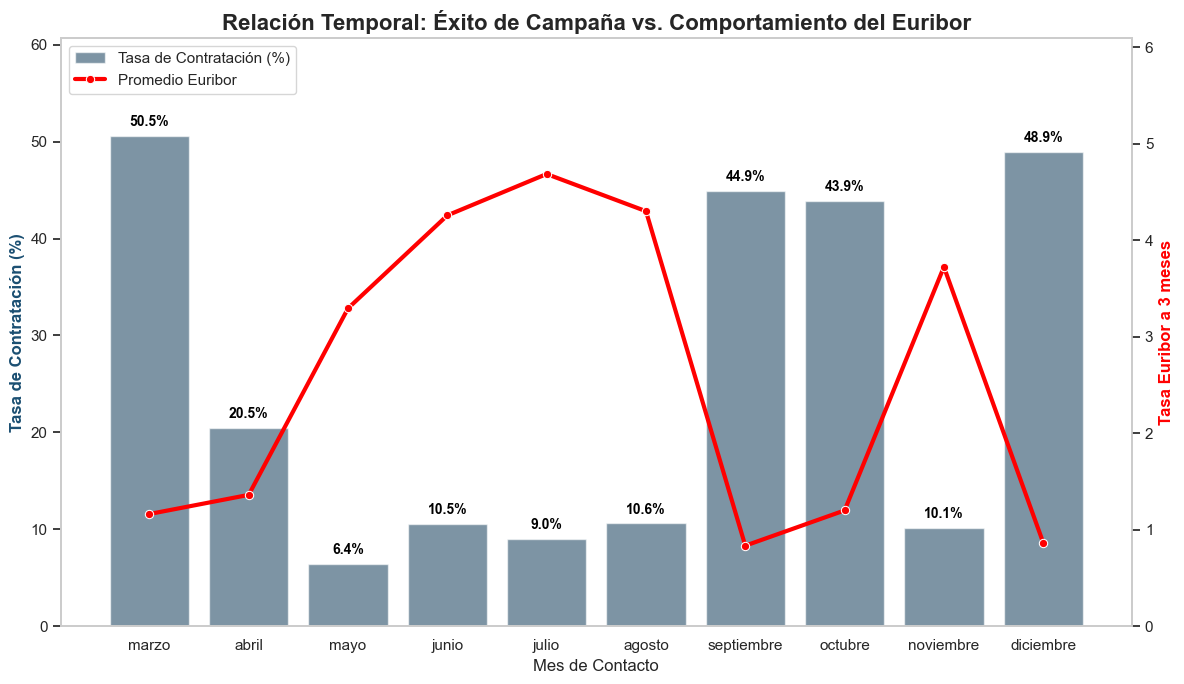

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gráfico de Relación: Mes vs Tasa de Contratación vs Euribor
fig, ax1 = plt.subplots(figsize=(12, 7))

# Puedes elegir el color de las barras aquí
color_barras = 'skyblue' 

# 1. Configuración del primer eje (Barras para la Tasa de Contratación)
orden_meses = ['marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']
tasa_mes = df.groupby('month')['y'].mean().reindex(orden_meses) * 100

sns.barplot(x=tasa_mes.index, y=tasa_mes.values, alpha=0.6, color='#1B4F72', label='Tasa de Contratación (%)', ax=ax1)
ax1.set_ylabel('Tasa de Contratación (%)', fontsize=12, fontweight='bold', color='#1B4F72')
ax1.set_xlabel('Mes de Contacto', fontsize=12)

# --- NUEVO: Añadimos los porcentajes sobre las barras ---
for p in ax1.patches:
    altura = p.get_height()
    if not pd.isna(altura) and altura > 0:
        # Formateamos a 1 decimal y añadimos el símbolo %
        ax1.annotate(f'{altura:.1f}%', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points', 
                    fontweight='bold', color='black', fontsize=10)

# Ampliamos el eje Y de las barras un 20% para que los números no choquen con el techo
ax1.set_ylim(0, tasa_mes.max() * 1.20)

# 2. Configuración del segundo eje (Línea para el Euribor promedio)
ax2 = ax1.twinx() 
euribor_mes = df.groupby('month')['euribor3m'].mean().reindex(orden_meses)

sns.lineplot(x=euribor_mes.index, y=euribor_mes.values, color='red', marker='o', linewidth=3, label='Promedio Euribor', ax=ax2)
ax2.set_ylabel('Tasa Euribor a 3 meses', fontsize=12, fontweight='bold', color='red')

# Ampliamos también el eje Y del Euribor un 30% para empujar la línea hacia abajo si es necesario, evitando que tache los números
ax2.set_ylim(0, euribor_mes.max() * 1.30)

# Detalles finales
plt.title('Relación Temporal: Éxito de Campaña vs. Comportamiento del Euribor', fontsize=16, fontweight='bold')
ax1.grid(False) # Limpiamos el fondo
ax2.grid(False)

# Solución para la leyenda superpuesta
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

# Leyenda unificada
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

## Gráfico 15: Matriz de Correlación (Conclusión Técnica)

15. Validación Técnica: Matriz de Correlación Lineal (Heatmap)

Justificación: Como culminación del Análisis Exploratorio de Datos, el heatmap resume las relaciones lineales entre todas las variables numéricas y la variable objetivo codificada (y). Esta visualización no solo revela qué atributos tienen mayor peso predictivo, sino que fundamenta las decisiones del preprocesamiento, como la detección de multicolinealidad entre índices macroeconómicos, asegurando la robustez del futuro modelo de Machine Learning y manteniendo la integridad en el manejo de datos.

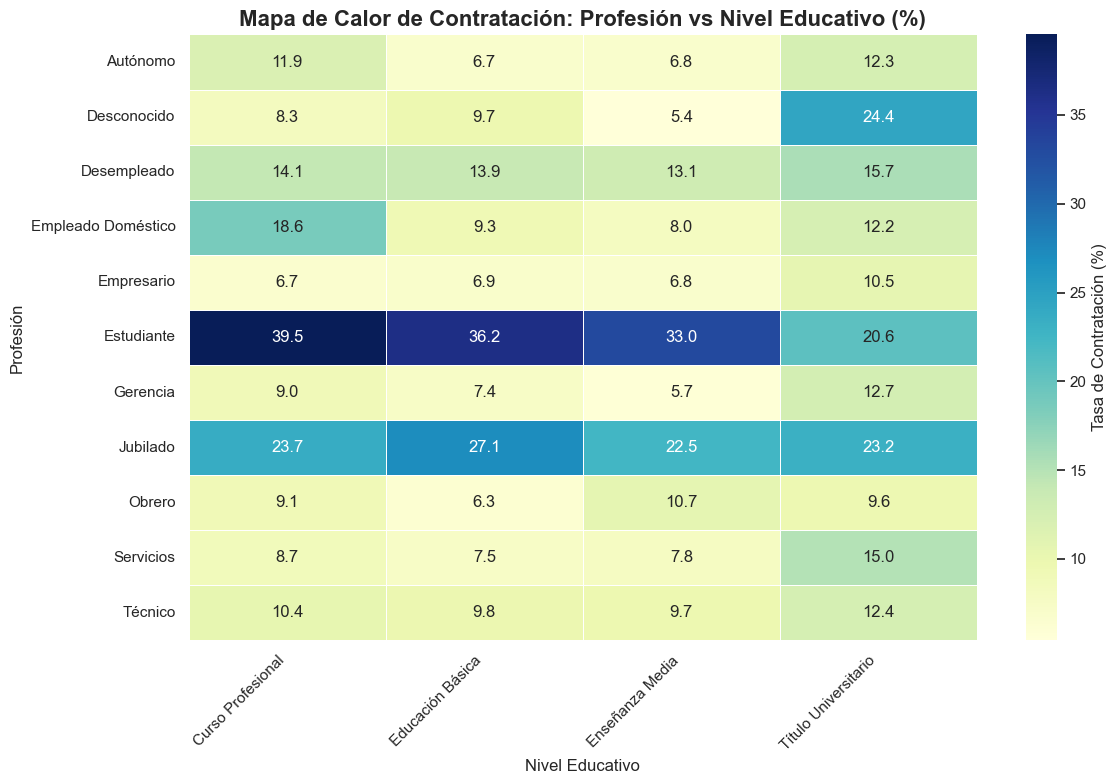

In [32]:
# Gráfico 15: Mapa de Calor de Contratación: Profesión vs Nivel Educativo
plt.figure(figsize=(12, 8))

# 1. Diccionarios de traducción (Consistentes con los gráficos 4 y 5)
trad_profesiones = {
    'admin.': 'Administrativo', 'blue-collar': 'Obrero', 'entrepreneur': 'Empresario',
    'housemaid': 'Empleado Doméstico', 'management': 'Gerencia', 'retired': 'Jubilado',
    'self-employed': 'Autónomo', 'services': 'Servicios', 'student': 'Estudiante',
    'technician': 'Técnico', 'unemployed': 'Desempleado', 'unknown': 'Desconocido'
}

trad_educacion = {
    'basic': 'Educación Básica',
    'high.school': 'Enseñanza Media',
    'professional.course': 'Curso Profesional',
    'university.degree': 'Título Universitario',
    'unknown': 'Desconocido'
}

# 2. Aplicamos las traducciones a una copia temporal
df_plot_heat = df.copy()
df_plot_heat['job'] = df_plot_heat['job'].map(trad_profesiones)
df_plot_heat['education'] = df_plot_heat['education'].map(trad_educacion)

# 3. Creamos la tabla dinámica para el mapa de calor (Promedio de 'y' * 100)
heatmap_data = pd.pivot_table(df_plot_heat, values='y', index='job', columns='education', aggfunc='mean') * 100

# 4. Generamos el heatmap con Seaborn
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, 
            cbar_kws={'label': 'Tasa de Contratación (%)'})

plt.title('Mapa de Calor de Contratación: Profesión vs Nivel Educativo (%)', fontsize=16, fontweight='bold')
plt.xlabel('Nivel Educativo', fontsize=12)
plt.ylabel('Profesión', fontsize=12)

# Ajuste estético de las etiquetas
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()